# AIE301M Prototype - RL Trading + Regime Inference

Surprise working prototype on the `Prototype` branch.

Sections:
1. Sim sanity check
2. Regime dataset
3. Regime classifier
4. Trading experiment (heuristics + DQN)
5. Ablation: DQN vs DQN + regime
6. Headline verdict (H1, H2, H3)


In [1]:
import os, sys
sys.path.insert(0, os.getcwd())
os.environ.setdefault("MPLBACKEND", "Agg")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
N_TICKS = 800
N_EPISODES = 10
N_SEEDS = 2
N_DATASET_TICKS = 2000

np.random.seed(SEED)
print("ready")


ready


## 1. Simulator sanity


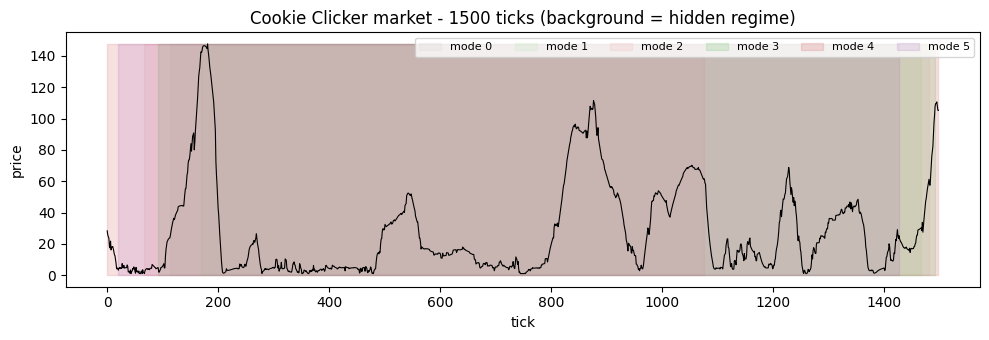

feature vector at last tick: [ 1.77766579e+01  1.58439213e-02 -9.33181042e-03 -2.89304497e-02
  1.74782887e+01  1.69380264e+01  8.00022809e-01  3.18964171e-02]


In [2]:
import sys, os
_here = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
_project_root = _here if os.path.isdir(os.path.join(_here, 'sim')) else os.path.dirname(_here)
sys.path.insert(0, _project_root)
os.chdir(_project_root)
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)
from sim.market_sim import CookieClickerMarket

market = CookieClickerMarket(seed=SEED)
prices = []
modes = []
for _ in range(1500):
	market.tick()
	prices.append(market.current_prices[0])
	modes.append(market.current_modes[0])

fig, ax = plt.subplots(figsize=(10, 3.5))
mode_colors = ['#cccccc', '#a8e6a3', '#f4a3a3', '#3aaf3a', '#c33', '#9b59b6']
for m in range(6):
	mask = np.array(modes) == m
	if mask.any():
		ax.fill_between(np.where(mask)[0], 0, max(prices), color=mode_colors[m], alpha=0.15, label=f'mode {m}')
ax.plot(prices, color='black', lw=0.8)
ax.set_title('Cookie Clicker market - 1500 ticks (background = hidden regime)')
ax.set_xlabel('tick')
ax.set_ylabel('price')
ax.legend(loc='upper right', ncol=6, fontsize=8)
fig.tight_layout()
fig.savefig('results/price_chart.png', dpi=110)
plt.show()
print('feature vector at last tick:', market.get_observation(reveal=False)[0])


## 2. Regime dataset


In [3]:
import sys, os
_here = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
_project_root = _here if os.path.isdir(os.path.join(_here, 'sim')) else os.path.dirname(_here)
sys.path.insert(0, _project_root)
os.chdir(_project_root)
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)
from sim.market_sim import generate_regime_dataset

ds_path = 'data/regime_dataset.parquet'
import os
if not os.path.exists(ds_path):
	generate_regime_dataset(n_ticks=N_DATASET_TICKS, n_stocks=1, seed=SEED, out_path=ds_path)
df = pd.read_parquet(ds_path)
print('rows:', len(df), 'columns:', list(df.columns))
print('class balance:')
print(df['mode'].value_counts().sort_index())


rows: 2000 columns: ['tick', 'stock_id', 'price', 'return_1', 'return_5', 'return_20', 'rolling_mean_5', 'rolling_mean_20', 'rolling_std_20', 'momentum_5_20', 'mode']
class balance:
mode
0    384
1    610
2    347
3    154
4    210
5    295
Name: count, dtype: int64


## 3. Regime classifier


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogReg         accuracy=0.425 f1=0.288


RandomForest   accuracy=0.270 f1=0.233


MLP            accuracy=0.427 f1=0.343
 -> saved data/regime_classifier.joblib (used by DQN+Regime)


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


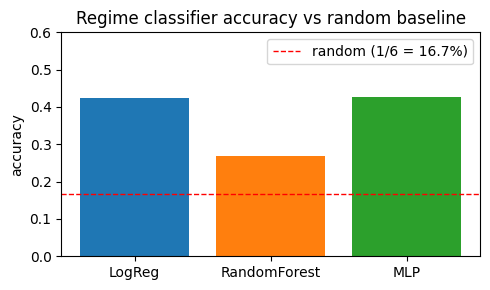

In [4]:
import sys, os
_here = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
_project_root = _here if os.path.isdir(os.path.join(_here, 'sim')) else os.path.dirname(_here)
sys.path.insert(0, _project_root)
os.chdir(_project_root)
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)
from eval.classifier.regime_classifier import (
	fit_one, make_logreg, make_random_forest, make_mlp,
	save_classifier, FEATURE_COLS,
)

X = df[FEATURE_COLS].to_numpy(dtype=np.float64)
y = df['mode'].to_numpy(dtype=np.int64)
split = int(0.7 * len(X))
X_tr, y_tr = X[:split], y[:split]
X_te, y_te = X[split:], y[split:]

df_tr = pd.DataFrame(X_tr, columns=FEATURE_COLS)
df_tr['mode'] = y_tr
df_te = pd.DataFrame(X_te, columns=FEATURE_COLS)
df_te['mode'] = y_te

results = []
for name, factory in [('LogReg', make_logreg), ('RandomForest', make_random_forest), ('MLP', make_mlp)]:
	m = fit_one(name, factory(), df_tr, df_te)
	print(f"{name:14s} accuracy={m.accuracy:.3f} f1={m.f1_macro:.3f}")
	results.append({'classifier': name, 'accuracy': m.accuracy, 'f1_macro': m.f1_macro})
	if name == 'MLP':
		save_classifier(m, 'data/regime_classifier.joblib')
		print(' -> saved data/regime_classifier.joblib (used by DQN+Regime)')

res_df = pd.DataFrame(results)
res_df.to_csv('results/exp2_classifiers_notebook.csv', index=False)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(res_df['classifier'], res_df['accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.axhline(1/6, color='red', ls='--', lw=1, label='random (1/6 = 16.7%)')
ax.set_ylabel('accuracy')
ax.set_ylim(0, 0.6)
ax.set_title('Regime classifier accuracy vs random baseline')
ax.legend()
fig.tight_layout()
fig.savefig('results/exp2_accuracy.png', dpi=110)
plt.show()


## 4. Trading experiment - Random / Buy&Hold / MeanRev / DQN


 seed=0 Random         return=-60.84% dd=0.97
 seed=0 BuyAndHold     return=+1424.75% dd=0.48
 seed=0 MeanReversion  return=+755.04% dd=0.95


 seed=1 Random         return=+75.24% dd=0.96
 seed=1 BuyAndHold     return=+286.40% dd=0.54
 seed=1 MeanReversion  return=-99.41% dd=1.00


 training DQN seed=0 ...


 DQN seed=0 return=+16596210.88% trades=655
 training DQN seed=1 ...


 DQN seed=1 return=+541935.55% trades=788


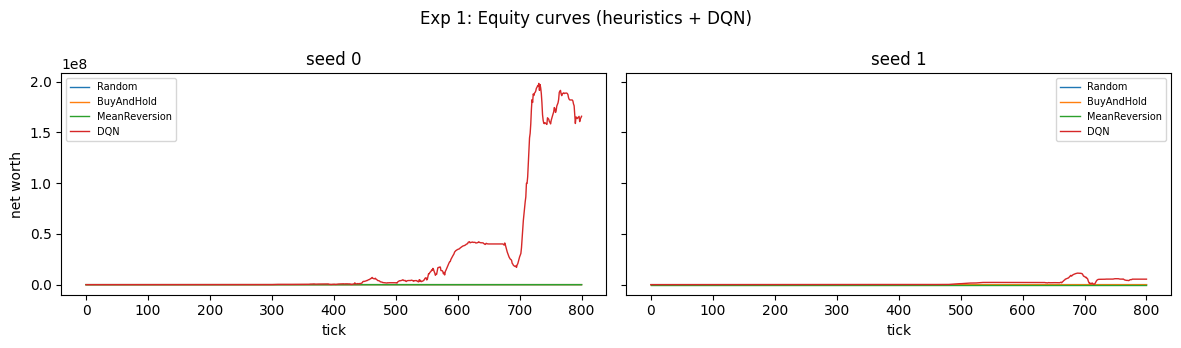

In [5]:
import sys, os
_here = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
_project_root = _here if os.path.isdir(os.path.join(_here, 'sim')) else os.path.dirname(_here)
sys.path.insert(0, _project_root)
os.chdir(_project_root)
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)
from eval.env.trading_env import TradingEnv
from eval.baselines.heuristics import RandomTrader, BuyAndHoldTrader, MeanReversionTrader
from eval.agents.dqn import DQNAgent, DQNConfig
from eval.agents.train import train_dqn, evaluate_dqn
from sim.market_sim import CookieClickerMarket
from eval.harness.run_experiments import _eval_heuristic


def env_factory(seed, tmax=N_TICKS):
	return TradingEnv(market=CookieClickerMarket(seed=seed), tmax=tmax)


rows = []
curves = {}
for seed in range(N_SEEDS):
	for name, cls in [
		('Random', lambda: RandomTrader(seed=seed)),
		('BuyAndHold', BuyAndHoldTrader),
		('MeanReversion', MeanReversionTrader),
	]:
		env = env_factory(seed * 1000 + 7)
		m = _eval_heuristic(env, cls())
		m['seed'] = seed
		m['trader'] = name
		rows.append(m)
		curves[f'{name}_{seed}'] = m['equity_curve']
		print(f" seed={seed} {name:14s} return={m['return_pct']:+.2%} dd={m['max_drawdown']:.2f}")

for seed in range(N_SEEDS):
	agent = DQNAgent(
		DQNConfig(input_dim=11, warmup=200, eps_decay_steps=N_EPISODES*N_TICKS//2),
		use_regime=False,
	)
	print(f" training DQN seed={seed} ...")
	train_dqn(
		lambda: env_factory(seed*1000+7),
		agent,
		n_episodes=N_EPISODES,
		episode_length=N_TICKS,
		verbose=False,
	)
	m = evaluate_dqn(lambda: env_factory(seed*1000+7), agent, episode_length=N_TICKS)
	m['seed'] = seed
	m['trader'] = 'DQN'
	rows.append(m)
	curves[f'DQN_{seed}'] = m['equity_curve']
	print(f" DQN seed={seed} return={m['return_pct']:+.2%} trades={m['n_trades']}")

all_df = pd.DataFrame(rows)
all_df.to_csv('results/exp1_all_notebook.csv', index=False)

fig, axes = plt.subplots(1, N_SEEDS, figsize=(6*N_SEEDS, 3.5), sharey=True)
if N_SEEDS == 1:
	axes = [axes]
for i, ax in enumerate(axes):
	for name in ['Random', 'BuyAndHold', 'MeanReversion', 'DQN']:
		key = f'{name}_{i}'
		if key in curves:
			ax.plot(curves[key], label=name, lw=1.0)
	ax.set_title(f'seed {i}')
	ax.set_xlabel('tick')
	ax.legend(fontsize=7)
axes[0].set_ylabel('net worth')
fig.suptitle('Exp 1: Equity curves (heuristics + DQN)')
fig.tight_layout()
fig.savefig('results/exp1_equity_curves.png', dpi=110)
plt.show()


## 5. Ablation - DQN vs DQN+Regime


 training DQN seed=0 ...


 DQN seed=0 return=+31761284.51% dd=0.78
 training DQN seed=1 ...


 DQN seed=1 return=+216.06% dd=0.99
 training DQN+Regime seed=0 ...


 DQN+Regime seed=0 return=+155883235.43% dd=0.77
 training DQN+Regime seed=1 ...


 DQN+Regime seed=1 return=+7125430.89% dd=0.88


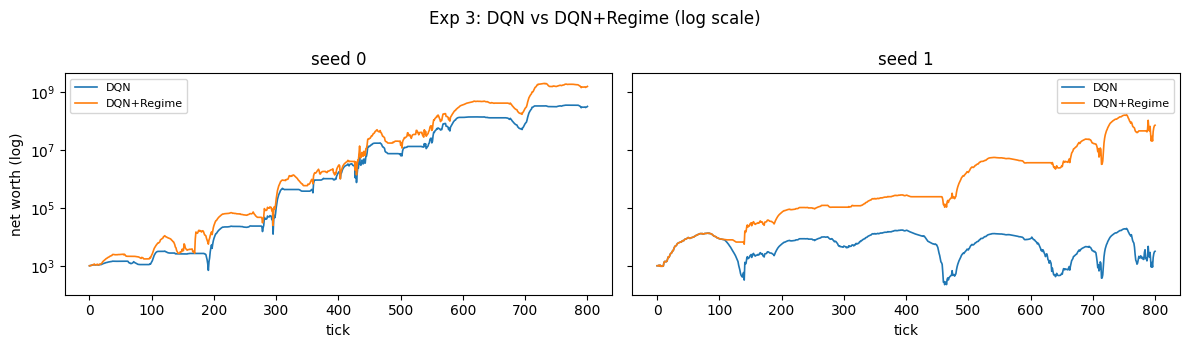

In [6]:
import sys, os
_here = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
_project_root = _here if os.path.isdir(os.path.join(_here, 'sim')) else os.path.dirname(_here)
sys.path.insert(0, _project_root)
os.chdir(_project_root)
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)
from eval.classifier.regime_classifier import load_classifier

clf = load_classifier('data/regime_classifier.joblib')


def regime_fn(obs):
	flat = obs.reshape(1, -1) if obs.ndim == 1 else obs.reshape(1, -1)
	p = clf.pipeline.predict_proba(flat)[0]
	if len(p) < 6:
		pad = np.zeros(6)
		pad[:len(p)] = p
		p = pad
	return p


rows = []
curves = {}
for use_regime in (False, True):
	variant = 'DQN+Regime' if use_regime else 'DQN'
	in_dim = 11 + (6 if use_regime else 0)
	for seed in range(N_SEEDS):
		agent = DQNAgent(
			DQNConfig(input_dim=in_dim, warmup=200, eps_decay_steps=N_EPISODES*N_TICKS//2),
			use_regime=use_regime,
		)
		print(f" training {variant} seed={seed} ...")
		train_dqn(
			lambda: env_factory(seed*1000+7),
			agent,
			n_episodes=N_EPISODES,
			episode_length=N_TICKS,
			regime_prob_fn=regime_fn if use_regime else None,
			verbose=False,
		)
		m = evaluate_dqn(
			lambda: env_factory(seed*1000+7),
			agent,
			episode_length=N_TICKS,
			regime_prob_fn=regime_fn if use_regime else None,
		)
		m['seed'] = seed
		m['variant'] = variant
		rows.append(m)
		curves[f'{variant}_{seed}'] = m['equity_curve']
		print(f" {variant} seed={seed} return={m['return_pct']:+.2%} dd={m['max_drawdown']:.2f}")

ab = pd.DataFrame(rows)
ab.to_csv('results/exp3_ablation_notebook.csv', index=False)

fig, axes = plt.subplots(1, N_SEEDS, figsize=(6*N_SEEDS, 3.5), sharey=True)
if N_SEEDS == 1:
	axes = [axes]
for i, ax in enumerate(axes):
	for variant in ['DQN', 'DQN+Regime']:
		key = f'{variant}_{i}'
		if key in curves:
			ax.plot(curves[key], label=variant, lw=1.2)
	ax.set_yscale('log')
	ax.set_title(f'seed {i}')
	ax.set_xlabel('tick')
	ax.legend(fontsize=8)
axes[0].set_ylabel('net worth (log)')
fig.suptitle('Exp 3: DQN vs DQN+Regime (log scale)')
fig.tight_layout()
fig.savefig('results/exp3_equity_curves.png', dpi=110)
plt.show()


## 6. Headline


In [7]:
import sys, os
_here = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
_project_root = _here if os.path.isdir(os.path.join(_here, 'sim')) else os.path.dirname(_here)
sys.path.insert(0, _project_root)
os.chdir(_project_root)
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)
mean_returns = all_df.groupby('trader')['return_pct'].mean()
h1 = (mean_returns.get('DQN', 0) > mean_returns.get('Random', 0)) and \
	(mean_returns.get('DQN', 0) > mean_returns.get('BuyAndHold', 0))
print('H1 (DQN > Random, Buy&Hold):', h1)
print(mean_returns.to_string())

best_clf = res_df['accuracy'].max()
h2 = best_clf > 1.0/6
print('H2 (best classifier > 1/6 = 16.7%):', h2, 'best=', round(best_clf, 3))

mean_ab = ab.groupby('variant')['return_pct'].mean()
h3 = mean_ab.get('DQN+Regime', 0) > mean_ab.get('DQN', 0)
print('H3 (DQN+Regime > DQN):', h3)
print(mean_ab.to_string())


H1 (DQN > Random, Buy&Hold): True
trader
BuyAndHold           8.555764
DQN              85690.732133
MeanReversion        3.278126
Random               0.072001
H2 (best classifier > 1/6 = 16.7%): True best= 0.427
H3 (DQN+Regime > DQN): True
variant
DQN           158807.502885
DQN+Regime    815043.331561
